In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Import the data from medical_examination.csv and assign it to the df variable.
df = pd.read_csv('medical_examination.csv')

# 2. Add an overweight column to the data. To determine if a person is overweight,
#    first calculate their BMI by dividing their weight in kilograms by the square of their height in meters.
#    If that value is > 25 then the person is overweight. Use the value 0 for NOT overweight and the value 1 for overweight.
df['overweight'] = np.where((df['weight'] / (df['height'] * 0.01)**2) > 25, 1, 0)

# 3. Normalize data by making 0 always good and 1 always bad.
#    If the value of cholesterol or gluc is 1, set the value to 0. If the value is more than 1, set the value to 1.
df[['cholesterol', 'gluc']] = np.where(df[['cholesterol', 'gluc']] == 1, 0, 1)

In [3]:
# 4. Draw the Categorical Plot in the draw_cat_plot function.
def draw_cat_plot():
    # 5. Create a DataFrame for the cat plot using pd.melt with values from cholesterol, gluc, smoke, alco, active, and overweight
    #    in the df_cat variable.
    df_melted = df.melt(id_vars=['cardio'], value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'])

    # 6. Group and reformat the data in df_cat to split it by cardio.
    #    Show the counts of each feature. You will have to rename one of the columns for the catplot to work correctly.
    df_grouped_counted_renamed = df_melted.groupby('cardio').value_counts().to_frame().rename(columns={'count': 'total'}).sort_index()

    # 7. Convert the data into long format and create a chart that shows the value counts of the categorical features
    #    using the following method provided by the seaborn library import: sns.catplot().
    chart = sns.catplot(df_grouped_counted_renamed, kind='bar', x='variable', y='total', hue='value', col='cardio')

    # 8. Get the figure for the output and store it in the fig variable.
    fig = chart.fig

    # 9. Do not modify the next two lines.
    fig.savefig('catplot.png')
    return fig

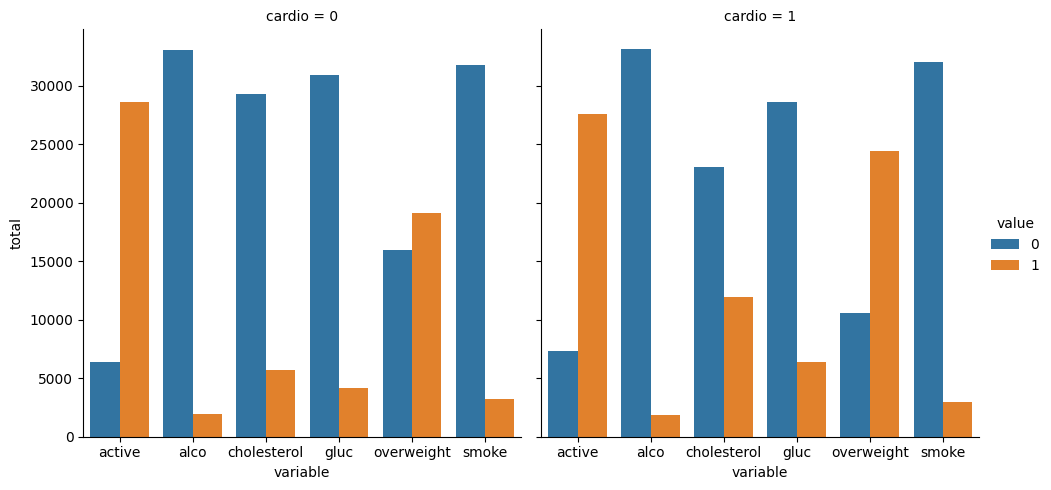

In [14]:
draw_cat_plot();

In [5]:
# 10. Draw the Heat Map in the draw_heat_map function.
def draw_heat_map():
    # 11. Clean the data in the df_heat variable by filtering out the following patient segments that represent incorrect data:
    #     diastolic pressure is higher than systolic (Keep the correct data with (df['ap_lo'] <= df['ap_hi']))
    #     height is less than the 2.5th percentile (Keep the correct data with (df['height'] >= df['height'].quantile(0.025)))
    #     height is more than the 97.5th percentile
    #     weight is less than the 2.5th percentile
    #     weight is more than the 97.5th percentile
    df_heat = df[
        (df['height'] >= df['height'].quantile(0.025)) &
        (df['height'] <= df['height'].quantile(0.975)) &
        (df['weight'] >= df['weight'].quantile(0.025)) &
        (df['weight'] <= df['weight'].quantile(0.975)) &
        (df['ap_lo'] <= df['ap_hi'])]

    # 12. Calculate the correlation matrix and store it in the corr variable.
    corr = df_heat.corr()

    # 13. Generate a mask for the upper triangle and store it in the mask variable.
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 14. Set up the matplotlib figure.
    fig, ax = plt.subplots(figsize=(7, 7))

    # 15. Plot the correlation matrix using the method provided by the seaborn library import: sns.heatmap().
    font_size = 8
    sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', square=True, linewidths=0.5, vmax=0.25, vmin=-0.1, center=0, annot_kws={'size': font_size})
    ax.tick_params(labelsize=font_size)
    ax.collections[0].colorbar.ax.tick_params(labelsize=font_size)

    # 16. Do not modify the next two lines.
    fig.savefig('heatmap.png')
    return fig

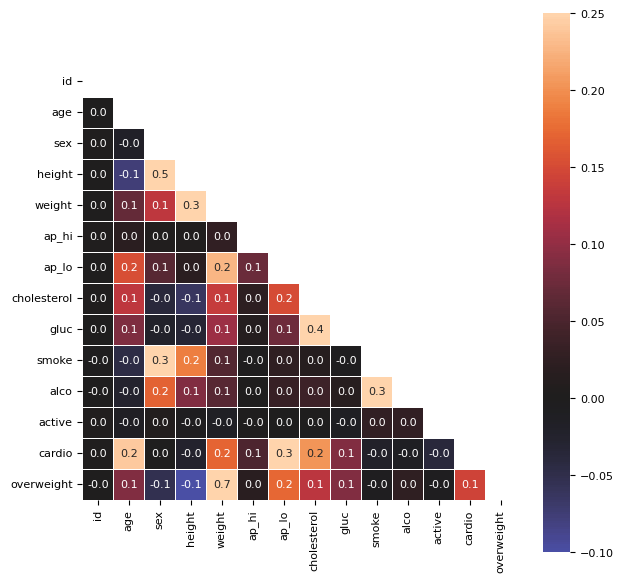

In [15]:
draw_heat_map();